In [456]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [457]:
import doralite
import gfdl_utils.core as gu
import CM4Xutils
import xarray as xr
import numpy as np

In [458]:
odiv_projects = doralite.list_project("odiv")['project']
OM5_experiments = [e for e in odiv_projects if e['title'] == "OM5 experiments"][0]['experiments'];

In [459]:
def load(var_dict, exp, dmget=True, mirror=False):
    pp = doralite.dora_metadata(exp)['pathPP']
    
    ds_list = []
    for (ppname, var_list) in var_dict.items():
        local = gu.get_local(pp, ppname, "ts")
        ds = gu.open_frompp(pp, ppname, "ts", local, "*", var_list, engine="netcdf4", dmget=dmget, mirror=mirror, chunks={'time':1})
        ds_list.append(ds)
        
    ds = xr.merge(ds_list)
    grid = gu.open_static(pp, "ocean_annual_z")
    sg = None
    
    if exp=="odiv-255":
        sgpath = (
            "/archive/Raphael.Dussin/datasets/OM4p125"
            "/mosaic_c192_om4p125_bedmachine_v20210310_hydrographyKDunne20210614_unpacked/"
            "ocean_hgrid.nc"
        )
        sg  = xr.open_dataset(sgpath)
        grid = CM4Xutils.fix_geo_coords(grid, sg)
        
    ds = ds.assign_coords({
        "areacello": xr.DataArray(grid.areacello.values, dims=("yh", "xh",)),
        "deptho"   : xr.DataArray(grid.deptho.values, dims=("yh", "xh",)),
        "geolon"   : xr.DataArray(grid.geolon.values, dims=("yh", "xh",)),
        "geolat"   : xr.DataArray(grid.geolat.values, dims=("yh", "xh",))
    })
    ds['thkcello'] = ds.volcello / ds.areacello
    
    return ds

In [460]:
var_dict = {
    "ocean_annual": ["volcello", "thetao", "so"],
    "ocean_annual_z": ["Kd_BBL", "Kd_shear", "Kd_itides"],
}

ds = load(var_dict, "odiv-339")

Issuing dmget command to migrate data to disk. Migration complete.
Issuing dmget command to migrate data to disk. Migration complete.


In [461]:
import cmocean
import matplotlib.pyplot as plt

cmap = cmocean.cm.deep
pckw = {"cmap":cmap, "vmin":3600, "vmax":5100}
ctkw = {"levels":[4550], "colors":"w", "linewidths":0.75}

xslice = [-171, -167]
yslice = [-10.9, -6.]

xlim = [-169.75, -168.25]
ylim = [-10, -7.5]

In [462]:
ds = ds.sel(
    xh=slice(*xslice),
    yh=slice(*yslice),
)

In [463]:
section = [
    (7,3),
    (7,4),
    (7,5),
    (8,5),
    (8,6),
    (8,7),
    (8,8),
    (8,9),
    (9,9),
    (9,10),
    (9,11),
    (9,12)
]
section = xr.Dataset({
    "cell": xr.DataArray(np.arange(0, len(section)), dims=("cell",)),
    "xh": xr.DataArray(ds.xh[[e[0] for e in section]].values, dims=("cell",)),
    "yh": xr.DataArray(ds.yh[[e[1] for e in section]].values, dims=("cell",))
})

ds_section = ds.sel(xh=section.xh, yh=section.yh)

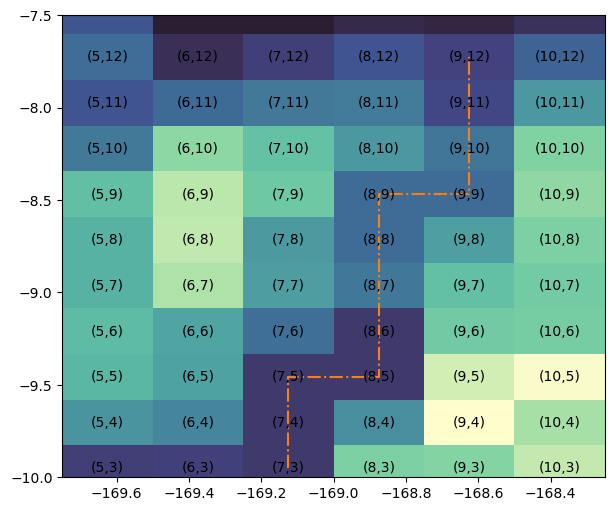

In [464]:
fig, ax = plt.subplots(1,1,figsize=(7, 6))

ax.pcolormesh(
    ds.geolon,
    ds.geolat,
    ds.deptho,
    vmin=4000, vmax=5500, cmap=cmap
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

for i, xh in enumerate(ds.xh):
    for j, yh in enumerate(ds.yh):
        c = (ds.geolon.sel(xh=xh, yh=yh), ds.geolat.sel(xh=xh, yh=yh))
        ax.annotate(f"({i},{j})", c, xytext=c, ha="center", va="center")
        
plt.plot(ds_section['geolon'], ds_section['geolat'], "C1-.")

In [465]:
ds_section.to_netcdf("/work/hfd/projects/DeepChannels/data/IconicSamoanPassage_OM5p25_JRA55.nc")

In [466]:
xslice = [-180, -175]

var_dict = {
    "ocean_annual": ["volcello", "thetao", "so"],
}

ds = load(var_dict, "odiv-255")

Issuing dmget command to migrate data to disk. Migration complete.


In [467]:
ds = ds.sel(
    xh=slice(*xslice),
    yh=slice(*yslice),
)

In [468]:
section = [
    (29, 7),
    (29, 8),
    (29, 9),
    (30, 9),
    (30,10),
    (30,11),
    (30,12),
    (30,13),
    (30,14),
    (30,15),
    (30,16),
    (30,17),
    (30,18),
    (31,18),
    (31,19),
    (32,19),
    (32,20),
    (32,21),
    (32,22),
    (32,23),
    (32,24),
    (32,25),
    (32,26),
]
section = xr.Dataset({
    "cell": xr.DataArray(np.arange(0, len(section)), dims=("cell",)),
    "xh": xr.DataArray(ds.xh[[e[0] for e in section]].values, dims=("cell",)),
    "yh": xr.DataArray(ds.yh[[e[1] for e in section]].values, dims=("cell",))
})

ds_section = ds.sel(xh=section.xh, yh=section.yh)

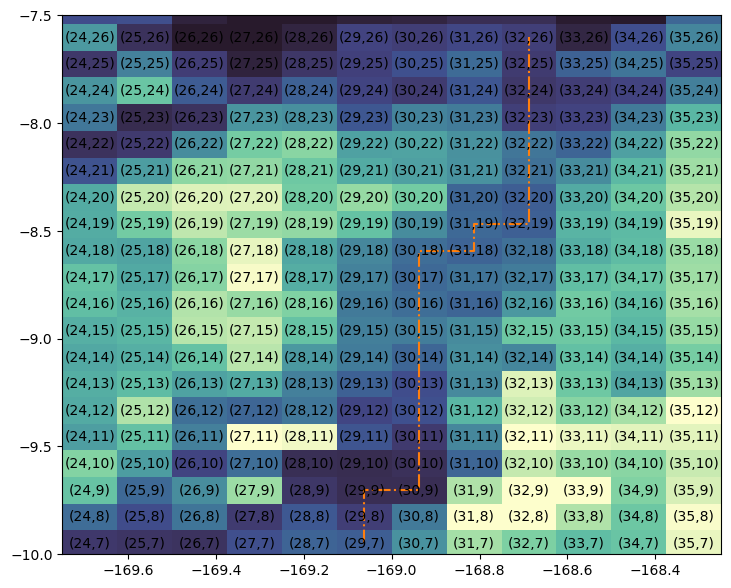

In [469]:
fig, ax = plt.subplots(1,1,figsize=(8.5, 7))

ax.pcolormesh(
    ds.geolon,
    ds.geolat,
    ds.deptho,
    vmin=4000, vmax=5500, cmap=cmap
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

for i, xh in enumerate(ds.xh):
    for j, yh in enumerate(ds.yh):
        c = (ds.geolon.sel(xh=xh, yh=yh), ds.geolat.sel(xh=xh, yh=yh))
        ax.annotate(f"({i},{j})", c, xytext=c, ha="center", va="center")
        
plt.plot(ds_section['geolon'], ds_section['geolat'], "C1-.");

In [470]:
ds_section.to_netcdf("/work/hfd/projects/DeepChannels/data/IconicSamoanPassage_CM4p125X_historical.nc")

## Plotting models sections

In [331]:
Kd = ds.sel(xh=section.xh, yh=section.yh)['Kd_BBL'].mean('time').compute()
T = ds.sel(xh=section.xh, yh=section.yh)['thetao'].mean('time').compute()
h = ds_section['thkcello'].cumsum("zl").isel(time=0).compute()

(0.0, 11.0)

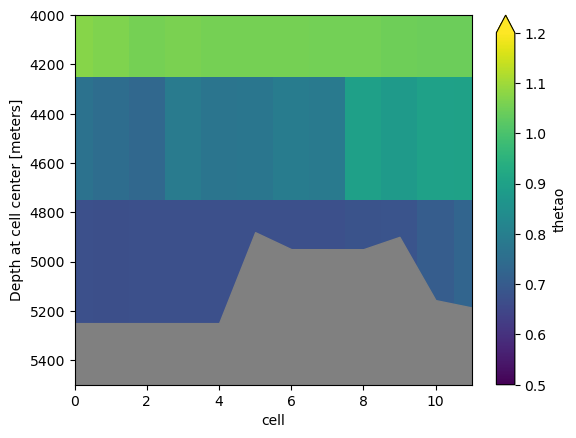

In [294]:
T.plot(vmin=0.5, vmax=1.2)
plt.fill_between(grid_section.cell, grid_section.deptho*0+6000, grid_section.deptho, color="gray")
plt.ylim(5500, 4000)
plt.xlim(0, grid_section.cell.max())

(5500.0, 3000.0)

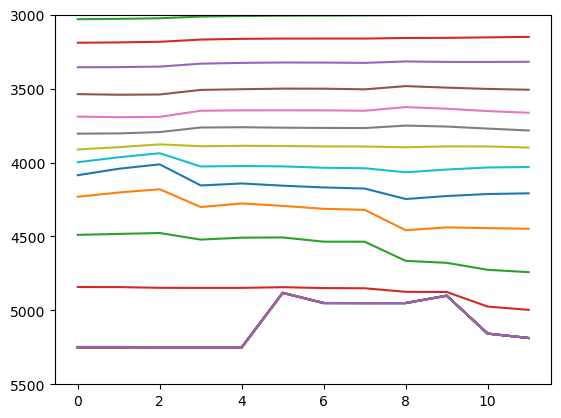

In [330]:
for zl in h.zl:
    plt.plot(h.cell, h.sel(zl=zl).values)
    
plt.ylim(5500, 3000)

In [ ]:
ds_section

(0.0, 11.0)

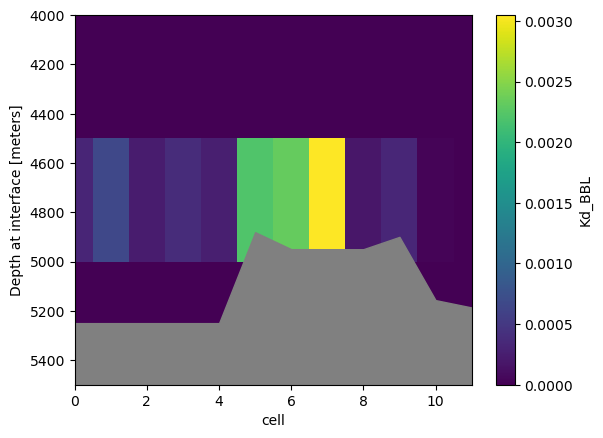

In [286]:
Kd.plot()
plt.fill_between(grid_section.cell, grid_section.deptho*0+6000, grid_section.deptho, color="gray")
plt.ylim(5500, 4000)
plt.xlim(0, grid_section.cell.max())

In [56]:
gebco = xr.open_dataset("/archive/gold/datasets/topography/GEBCO_2023/GEBCO_2023.nc").sel(lon=slice(*xslice), lat=slice(*yslice)).compute()

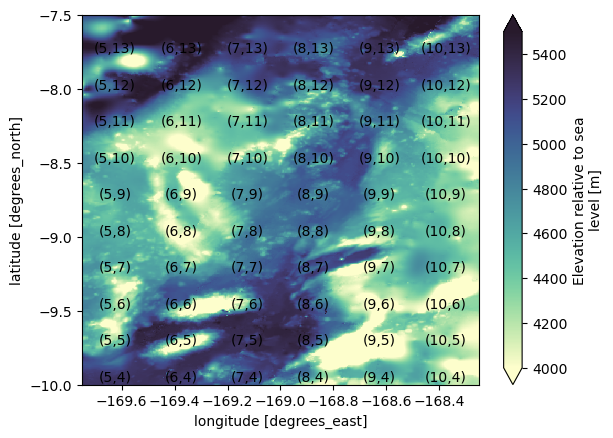

In [84]:
(-gebco['elevation']).sel(lon=slice(*xlim), lat=slice(*ylim)).plot(vmin=4000, vmax=5500, cmap=cmap)
plt.xlim(xlim)
plt.ylim(ylim);
ax = plt.gca()

for i, xh in enumerate(grid.xh):
    for j, yh in enumerate(grid.yh):
        c = (grid.geolon.sel(xh=xh, yh=yh), grid.geolat.sel(xh=xh, yh=yh))
        ax.annotate(f"({i},{j})", c, xytext=c, ha="center", va="center")

In [365]:
T = ds_section.thetao.mean('time').compute()
h = ds_section.thkcello.cumsum("zl").mean('time').compute()

(5500.0, 3000.0)

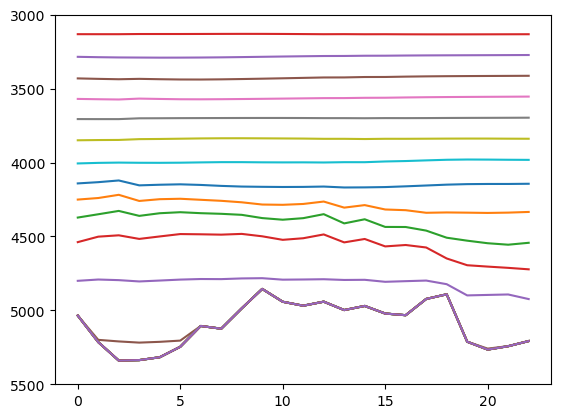

In [367]:
for zl in h.zl:
    plt.plot(h.cell, h.sel(zl=zl).values)
    
plt.ylim(5500, 3000)

(0.0, 22.0)

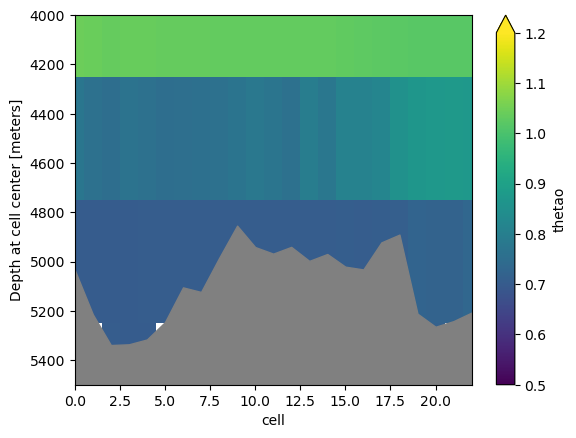

In [373]:
T.plot(vmin=0.5, vmax=1.2)
plt.fill_between(grid_section.cell, grid_section.deptho*0+6000, grid_section.deptho, color="gray")
plt.ylim(5500, 4000)
plt.xlim(0, grid_section.cell.max())